# Ionization rates in the LAr TPC

Rate of ionization charge deposited in the LAr, at the G4 level. This is before any detector response (recombination,
drift attenuation, electronics). Converts the truth-level deposited ionization energy to number of electrons based on the MeVtoElectrons conversion set in the options.xml (currently assumes energy to ionize LAr is 23.6, comes from https://lar.bnl.gov/properties/pass.html)

In [50]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('/nevis/wanaka/share/standon/GRAMS/GramsSim-tools')
from scripts.extract_df import extract_all_events
from scripts.config import PARTICLE_DICT, MAPS_DIR, TPC_DIMENSIONS, get_option

plt.style.use('~/latex-cm.mplstyle')
colors = sns.color_palette('colorblind')

particle_names = {k: v[0] for k, v in PARTICLE_DICT.items()}

MEV_TO_ELECTRONS = get_option('MeVToElectrons', 'gramsdetsim')  # electrons per MeV, from options file
ELEMENTARY_CHARGE_C = 1.602176634e-19                            # Coulombs per electron
print(f"MeVToElectrons = {MEV_TO_ELECTRONS:.4e} e-/MeV,  e = {ELEMENTARY_CHARGE_C:.3e} C")

MeVToElectrons = 4.2370e+04 e-/MeV,  e = 1.602e-19 C


In [24]:
# load unified dataframe
events_df = extract_all_events()

# calculate num electrons and then total charge deposited
events_df['n_electrons'] = events_df['total_ionization_energy'] * MEV_TO_ELECTRONS
events_df['charge'] = events_df['n_electrons'] * ELEMENTARY_CHARGE_C  # Coulombs

# normalize by primary energy
events_df['charge_per_mev'] = events_df['charge'] / events_df['primary_energy']

# load flux weights to converts (C/MeV) to (C/MeV/s)
with open(os.path.join(MAPS_DIR, 'pkl', 'weights.pkl'), 'rb') as f:
    weights = pickle.load(f)
print(f"Loaded weights for: {list(weights.keys())}")

[CACHE] Loading from /nevis/wanaka/data/standon/minigrams_occupancy/tucson_2025_8_31_maps/pkl/events.parquet
Loaded weights for: ['neutro', 'proton', 'he---4', 'muplus', 'mumins', 'electr', 'positr', 'photon']


## Per-event charge deposited

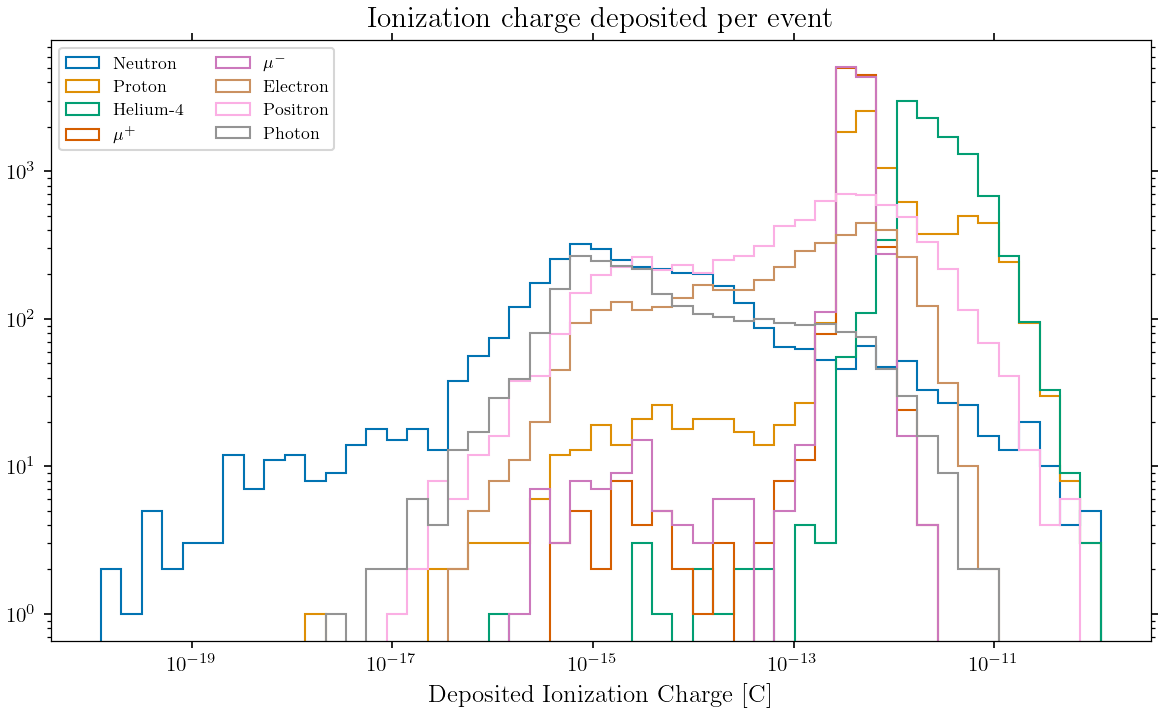

In [46]:
# histogram of per-event deposited charge, per particle (events with LAr hits).
hit = events_df[events_df['n_electrons'] > 0]

fig, ax = plt.subplots(figsize=(8, 5))
qvals = hit['charge']
bins = np.geomspace(qvals[qvals > 0].min(), qvals.max(), 50)

for i, p in enumerate(PARTICLE_DICT.keys()):
    q = hit.loc[hit['particle'] == p, 'charge']
    if len(q) == 0:
        continue
    ax.hist(q, bins=bins, histtype='step', linewidth=1,
            color=colors[i % len(colors)], label=particle_names[p])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Deposited Ionization Charge [C]')
ax.set_title('Ionization charge deposited per event')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Charge-deposition rate

In [44]:
# charge-deposition rate per particle, normalized to primary energy.
rows = []
for p in PARTICLE_DICT.keys():
    sub = events_df[events_df['particle'] == p]
    w = weights[p]['w']
    
    charge_rate = sub['charge_per_mev'].sum() * w  # C/MeV/s
    rows.append({
        'particle': particle_names[p],
        'charge_rate (C/MeV/s)': charge_rate,
    })

rate_df = pd.DataFrame(rows).set_index('particle')
total = rate_df.sum()
total.name = 'TOTAL'
rate_df_total = pd.concat([rate_df, total.to_frame().T])

pd.set_option('display.float_format', lambda v: f'{v:.4e}')
print(rate_df_total)

          charge_rate (C/MeV/s)
Neutron              7.7521e-15
Proton               1.6765e-14
Helium-4             1.0041e-15
$\mu^+$              4.3031e-15
$\mu^-$              3.9363e-15
Electron             1.2775e-13
Positron             1.3275e-13
Photon               4.5200e-12
TOTAL                4.8143e-12


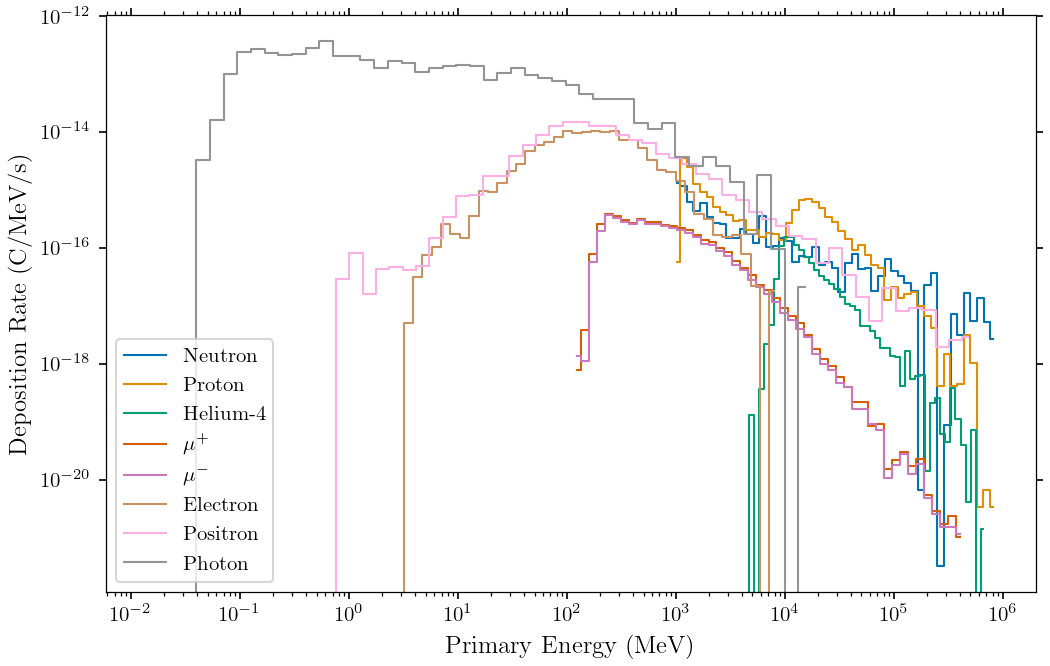

In [48]:
# plot the rates as a function of energy
plt.figure(figsize=(8, 5))
for i, p in enumerate(PARTICLE_DICT.keys()):
    sub = events_df[events_df['particle'] == p]
    w = weights[p]['w']
    
    # histogram of primary energy, weighted by charge deposition rate
    bins = np.geomspace(sub['primary_energy'].min(), sub['primary_energy'].max(), 50)
    hist, edges = np.histogram(sub['primary_energy'], bins=bins, weights=sub['charge_per_mev'] * w)
    centers = (edges[:-1] + edges[1:]) / 2
    
    plt.step(centers, hist, where='mid', linewidth=1,
             color=colors[i % len(colors)], label=particle_names[p])
plt.xlabel('Primary Energy (MeV)')
plt.ylabel('Deposition Rate (C/MeV/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [ ]:
# normalize by volume of TPC
tpc_vol = TPC_DIMENSIONS['x'] * TPC_DIMENSIONS['y'] * TPC_DIMENSIONS['z'] * 1e-6  # m^3

rows = []
for p in PARTICLE_DICT.keys():
    sub = events_df[events_df['particle'] == p]
    w = weights[p]['w']
    
    charge_rate = (sub['charge_per_mev'].sum() * w) / tpc_vol  # C/MeV/s
    rows.append({
        'particle': particle_names[p],
        'charge_rate (C/MeV/m3/s)': charge_rate,
    })

rate_df = pd.DataFrame(rows).set_index('particle')
total = rate_df.sum()
total.name = 'TOTAL'
rate_df_total = pd.concat([rate_df, total.to_frame().T])

pd.set_option('display.float_format', lambda v: f'{v:.4e}')
print(rate_df_total)

          charge_rate (C/MeV/m3/s)
Neutron                 8.6135e-13
Proton                  1.8628e-12
Helium-4                1.1157e-13
$\mu^+$                 4.7812e-13
$\mu^-$                 4.3736e-13
Electron                1.4194e-11
Positron                1.4750e-11
Photon                  5.0223e-10
TOTAL                   5.3492e-10
